# Understanding the Opioid Crisis: An Analysis of Overdose Trends Across States, Demographics, and Drug Types

Author: Alissa N. Beaderstadt<br>
Northwest Missouri State University, Maryville MO 64468, USA<br>
Email: S528352@nwmissouri.edu and alissabeaderstadt@outlook.com<br>

## Project Overview

This notebook performs exploratory data analysis (EDA) on opioid overdose mortality data obtained from CDC WONDER. The analysis uses one primary state-by-year dataset containing overall opioid overdose deaths and opioid subtype deaths, along with three supporting demographic datasets (age, sex, and race/ethnicity). The objective is to inspect data quality, summarize key characteristics, and explore trends and relationships in opioid overdose mortality.

## Section 1. Imports

In [1]:
from matplotlib.axes import Axes
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import kaleido

# Display settings
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Imports complete.")

Imports complete.


## Section 2. Load Processed Datasets
Before analysis, load the data to confirm:

- The dataset loads successfully
- The structure matches expectations
- Column names are available and readable

In [2]:
# Primary state-by-year dataset
master_df = pd.read_csv("../data/processed/merged_opioid_deaths.csv")

# Supporting demographic datasets
age_df = pd.read_csv("../data/processed/age_processed.csv")
sex_df = pd.read_csv("../data/processed/sex_processed.csv")
race_df = pd.read_csv("../data/processed/race_processed.csv")

## Section 3. Data Quality Assessment
Before beginning the analysis, the processed datasets were inspected for missing values, duplicate records, and overall completeness to ensure they were suitable for exploratory analysis.

### 3.1 Master Dataset

In [3]:
# Drop unnecessary columns for analysis
analysis_df = master_df.drop(columns=["state_code", "year_code"])

# Preview the shape and info of the cleaned master dataset
analysis_df.shape  # noqa: B018
print("Dataset shape:", analysis_df.shape)
analysis_df.info()

# Preview the first few rows
analysis_df.head()

Dataset shape: (1122, 15)
<class 'pandas.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   state                    1122 non-null   str    
 1   year                     1122 non-null   int64  
 2   opioid_deaths            1085 non-null   float64
 3   population               1122 non-null   float64
 4   opioid_death_rate        1040 non-null   float64
 5   heroin_deaths            811 non-null    float64
 6   heroin_death_rate        661 non-null    float64
 7   other_deaths             740 non-null    float64
 8   other_death_rate         518 non-null    float64
 9   methadone_deaths         913 non-null    float64
 10  methadone_death_rate     732 non-null    float64
 11  synthetic_deaths         858 non-null    float64
 12  synthetic_death_rate     643 non-null    float64
 13  prescription_deaths      1013 non-null   float64
 14  prescript

,state,year,opioid_deaths,population,opioid_death_rate,heroin_deaths,heroin_death_rate,other_deaths,other_death_rate,methadone_deaths,methadone_death_rate,synthetic_deaths,synthetic_death_rate,prescription_deaths,prescription_death_rate
0,Alabama,1999,26.00,"4,430,141.00",0.60,NaN,NaN,NaN,NaN,14.00,NaN,NaN,NaN,NaN,NaN
1,Alabama,2000,31.00,"4,447,100.00",0.70,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.00,NaN
2,Alabama,2001,47.00,"4,467,634.00",1.10,NaN,NaN,NaN,NaN,22.00,0.50,NaN,NaN,19.00,NaN
3,Alabama,2002,61.00,"4,480,089.00",1.40,NaN,NaN,NaN,NaN,30.00,0.70,NaN,NaN,26.00,0.60
4,Alabama,2003,40.00,"4,503,491.00",0.90,NaN,NaN,NaN,NaN,23.00,0.50,NaN,NaN,18.00,NaN


In [4]:
# Check for missing values in the cleaned master dataset
missing_summary = pd.DataFrame({
    "Missing Values": analysis_df.isna().sum(),
    "Percent Missing": (
        analysis_df.isna().mean() * 100
    ).round(2)
})

missing_summary.sort_values(
    "Percent Missing",
    ascending=False
)

print("Missing values summary:")
print(missing_summary.sort_values("Percent Missing", ascending=False))

Missing values summary:
                         Missing Values  Percent Missing
other_death_rate                    604            53.83
synthetic_death_rate                479            42.69
heroin_death_rate                   461            41.09
methadone_death_rate                390            34.76
other_deaths                        382            34.05
heroin_deaths                       311            27.72
synthetic_deaths                    264            23.53
prescription_death_rate             231            20.59
methadone_deaths                    209            18.63
prescription_deaths                 109             9.71
opioid_death_rate                    82             7.31
opioid_deaths                        37             3.30
population                            0             0.00
state                                 0             0.00
year                                  0             0.00


Although several opioid subtype variables contain substantial missingness due to CDC suppression policies, the primary outcome variable (overall opioid overdose deaths) is over 96% complete, providing a strong foundation for statewide trend analyses.

In [5]:
# Check for duplicate rows in the cleaned master dataset
analysis_df.duplicated(
    subset=["state", "year"]
).sum()
print(f"Duplicate rows in cleaned master dataset: {analysis_df.duplicated(subset=['state', 'year']).sum()}")

Duplicate rows in cleaned master dataset: 0


In [6]:
# Unique state values
analysis_df["state"].nunique()
print(f"Unique states in cleaned master dataset: {analysis_df['state'].nunique()}")

# Minimum year
analysis_df["year"].min()
print(f"Minimum year in cleaned master dataset: {analysis_df['year'].min()}")

# Maximum year
analysis_df["year"].max()
print(f"Maximum year in cleaned master dataset: {analysis_df['year'].max()}")

Unique states in cleaned master dataset: 51
Minimum year in cleaned master dataset: 1999
Maximum year in cleaned master dataset: 2020


*Summary of suppressed values:* <br>
The primary opioid deaths variable contains 37 missing observations (3.3% of the dataset). Examination of the original CDC WONDER files showed that these correspond to suppressed counts, primarily among smaller-population states during earlier years of the study period. These values were intentionally retained as NaN because they represent unavailable data rather than zero deaths.

### 3.2 Supporting Demographic Datasets
The supporting age, sex, and race/ethnicity datasets were also inspected to verify that they loaded correctly and were ready for analysis. These datasets were previously cleaned during preprocessing and therefore required only validation within the notebook.

In [7]:
# Drop unnecessary columns for analysis in demographic datasets
age_analysis_df = age_df.drop(columns=["state_code", "year_code"])
sex_analysis_df = sex_df.drop(columns=["state_code", "year_code"])
race_analysis_df = race_df.drop(columns=["state_code", "year_code"])

# Store supporting datasets for inspection
datasets = {
    "Age": age_analysis_df,
    "Sex": sex_analysis_df,
    "Race/Ethnicity": race_analysis_df,
}

# Preview each supporting dataset
for name, df in datasets.items():
    print(f"\n{name} Dataset")
    print(f"Shape: {df.shape}")
    df.info()
    display(df.head())


Age Dataset
Shape: (15155, 7)
<class 'pandas.DataFrame'>
RangeIndex: 15155 entries, 0 to 15154
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   state              15155 non-null  str    
 1   year               15155 non-null  float64
 2   single_year_ages   15155 non-null  str    
 3   age                15155 non-null  float64
 4   deaths             15155 non-null  float64
 5   population         15155 non-null  float64
 6   opioid_death_rate  6927 non-null   float64
dtypes: float64(5), str(2)
memory usage: 828.9 KB


,state,year,single_year_ages,age,deaths,population,opioid_death_rate
0,Alabama,"2,007.00",46 years,46.00,10.00,"69,977.00",NaN
1,Alabama,"2,013.00",34 years,34.00,10.00,"60,058.00",NaN
2,Alabama,"2,014.00",31 years,31.00,13.00,"61,793.00",NaN
3,Alabama,"2,014.00",36 years,36.00,12.00,"59,363.00",NaN
4,Alabama,"2,014.00",57 years,57.00,11.00,"68,354.00",NaN



Sex Dataset
Shape: (2244, 7)
<class 'pandas.DataFrame'>
RangeIndex: 2244 entries, 0 to 2243
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   state              2244 non-null   str    
 1   year               2244 non-null   float64
 2   sex                2244 non-null   str    
 3   sex_code           2244 non-null   str    
 4   deaths             2044 non-null   float64
 5   population         2244 non-null   float64
 6   opioid_death_rate  1833 non-null   float64
dtypes: float64(4), str(3)
memory usage: 122.8 KB


,state,year,sex,sex_code,deaths,population,opioid_death_rate
0,Alabama,"1,999.00",Female,F,10.00,"2,293,259.00",NaN
1,Alabama,"1,999.00",Male,M,16.00,"2,136,884.00",NaN
2,Alabama,"2,000.00",Female,F,12.00,"2,300,596.00",NaN
3,Alabama,"2,000.00",Male,M,19.00,"2,146,504.00",NaN
4,Alabama,"2,001.00",Female,F,19.00,"2,309,496.00",NaN



Race/Ethnicity Dataset
Shape: (4488, 7)
<class 'pandas.DataFrame'>
RangeIndex: 4488 entries, 0 to 4487
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   state              4488 non-null   str    
 1   year               4488 non-null   float64
 2   race               4488 non-null   str    
 3   race_code          4488 non-null   str    
 4   deaths             3083 non-null   float64
 5   population         4488 non-null   float64
 6   opioid_death_rate  1595 non-null   float64
dtypes: float64(4), str(3)
memory usage: 245.6 KB


,state,year,race,race_code,deaths,population,opioid_death_rate
0,Alabama,"1,999.00",American Indian or Alaska Native,1002-5,0.00,"22,667.00",NaN
1,Alabama,"1,999.00",Asian or Pacific Islander,A-PI,0.00,"33,495.00",NaN
2,Alabama,"1,999.00",Black or African American,2054-5,NaN,"1,162,673.00",NaN
3,Alabama,"1,999.00",White,2106-3,23.00,"3,211,308.00",0.70
4,Alabama,"2,000.00",American Indian or Alaska Native,1002-5,0.00,"25,386.00",NaN


In [8]:
# Create a summary of missing values across all datasets
missing_summary = pd.DataFrame({
    "Dataset": ["Master", "Age", "Sex", "Race"],
    "Rows": [
        analysis_df.shape[0],
        age_analysis_df.shape[0],
        sex_analysis_df.shape[0],
        race_analysis_df.shape[0],
    ],
    "Missing Deaths": [
        analysis_df["opioid_deaths"].isna().sum(),
        age_analysis_df["deaths"].isna().sum(),
        sex_analysis_df["deaths"].isna().sum(),
        race_analysis_df["deaths"].isna().sum(),
    ],
    "Missing Death Rates": [
        analysis_df["opioid_death_rate"].isna().sum(),
        age_analysis_df["opioid_death_rate"].isna().sum(),
        sex_analysis_df["opioid_death_rate"].isna().sum(),
        race_analysis_df["opioid_death_rate"].isna().sum(),
    ],
})

# Calculate percentages
missing_summary["% Missing Deaths"] = (
    missing_summary["Missing Deaths"] / missing_summary["Rows"] * 100
).round(2)

missing_summary["% Missing Death Rates"] = (
    missing_summary["Missing Death Rates"] / missing_summary["Rows"] * 100
).round(2)

missing_summary

,Dataset,Rows,Missing Deaths,Missing Death Rates,% Missing Deaths,% Missing Death Rates
0,Master,1122,37,82,3.30,7.31
1,Age,15155,0,8228,0.00,54.29
2,Sex,2244,200,411,8.91,18.32
3,Race,4488,1405,2893,31.31,64.46


In [9]:
# Check for dulpicate values in supporting datasets
duplicate_summary = pd.DataFrame({
    "Dataset": ["Age", "Sex", "Race"],
    "Duplicate Rows": [
        age_analysis_df.duplicated(
            subset=["state", "year", "age"]
        ).sum(),
        sex_analysis_df.duplicated(
            subset=["state", "year", "sex"]
        ).sum(),
        race_analysis_df.duplicated(
            subset=["state", "year", "race"]
        ).sum(),
    ]
})

duplicate_summary

,Dataset,Duplicate Rows
0,Age,0
1,Sex,0
2,Race,0


In [10]:
# Check the year range in supporting datasets
for name, df in datasets.items():
    print(
        f"{name}:",
        df["year"].min(),
        "-",
        df["year"].max()
    )

Age: 1999.0 - 2020.0
Sex: 1999.0 - 2020.0
Race/Ethnicity: 1999.0 - 2020.0


## Section 4. Descriptive Statistics (Master Dataset)

In [11]:
describe_df = analysis_df.describe().round(2)
print(describe_df)

          year  opioid_deaths    population  opioid_death_rate  heroin_deaths  heroin_death_rate  other_deaths  \
count 1,122.00       1,085.00      1,122.00           1,040.00         811.00             661.00        740.00   
mean  2,009.50         450.09  6,012,795.59               7.98         165.11               2.96         59.31   
std       6.35         630.81  6,756,332.37               7.23         230.92               2.73         80.66   
min   1,999.00           0.00    491,780.00               0.40           0.00               0.10          0.00   
25%   2,004.00          74.00  1,661,982.50               3.50          28.00               1.00         17.00   
50%   2,009.50         240.00  4,214,329.00               5.70          77.00               2.10         32.00   
75%   2,015.00         539.00  6,891,085.75               9.60         202.50               4.10         62.00   
max   2,020.00       5,313.00 39,557,045.00              62.00       1,445.00           

### Key Observations:

- The dataset spans 1999-2020 across 51 states.
- Median opioid deaths (240) are substantially lower than the mean (450), indicating a right-skewed distribution.
- Population varies considerably across states, highlighting the importance of examining death rates in addition to raw counts.


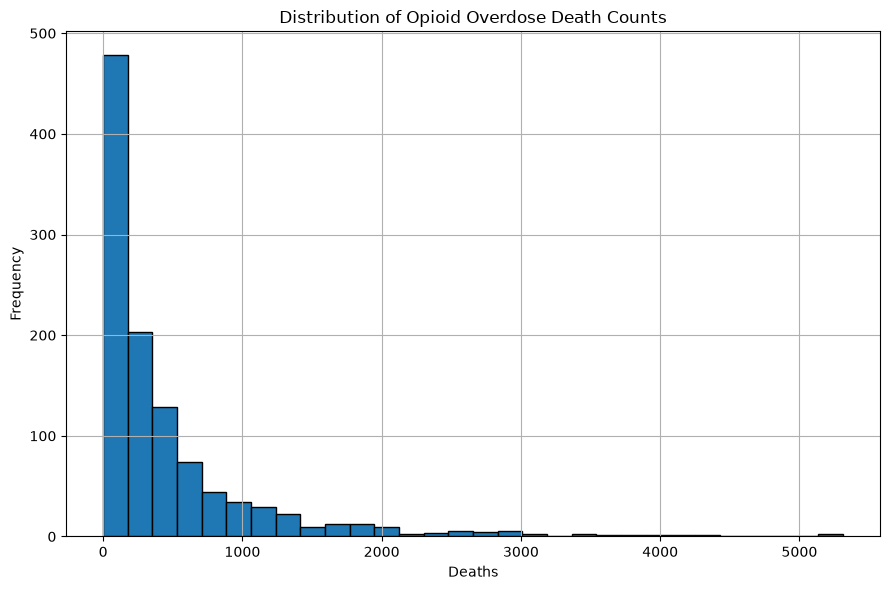

In [12]:
# Counts of deaths
plt.figure(figsize=(9,6))

analysis_df["opioid_deaths"].hist(
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Opioid Overdose Death Counts")
plt.xlabel("Deaths")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

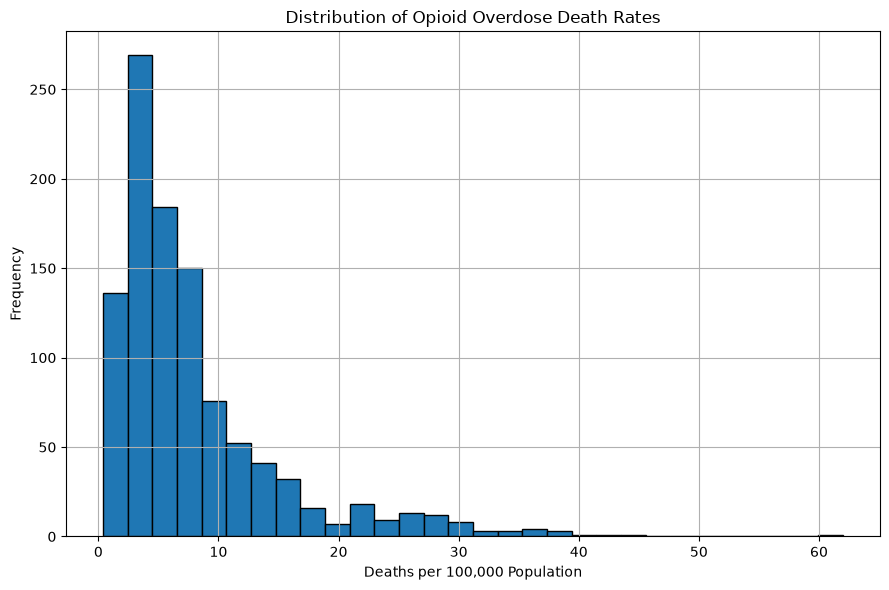

In [13]:
# rates
plt.figure(figsize=(9,6))

analysis_df["opioid_death_rate"].hist(
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Opioid Overdose Death Rates")
plt.xlabel("Deaths per 100,000 Population")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

The distribution of opioid overdose deaths is strongly right-skewed. Most state-year observations have relatively low numbers of overdose deaths, while a small number of highly populated states contribute exceptionally large counts. This suggests that analyses based on death rates may provide more meaningful comparisons across states than raw counts alone.

## Section 5. Exploratory Data Analysis

### 5.1 State-Level and Drug-Type Analysis

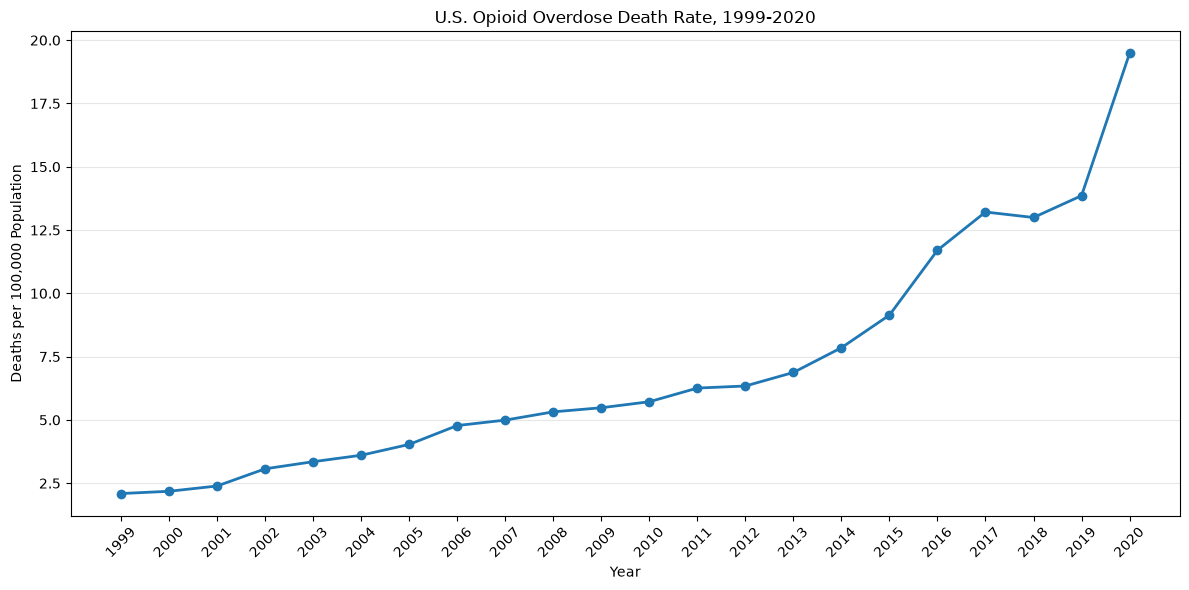

In [14]:
# National opioid mortality trend, 1999-2020

# Aggregate deaths and population by year
national_trend = (
    analysis_df.groupby("year", as_index=False)
    .agg(
        opioid_deaths=("opioid_deaths", "sum"),
        population=("population", "sum"),
    )
)

# Calculate national crude death rate per 100,000 population
national_trend["opioid_death_rate"] = (
    national_trend["opioid_deaths"]
    / national_trend["population"]
    * 100_000
)

# Create the time-series line chart
plt.figure(figsize=(12, 6))

plt.plot(
    national_trend["year"],
    national_trend["opioid_death_rate"],
    marker="o",
    linewidth=2,
)

plt.title("U.S. Opioid Overdose Death Rate, 1999-2020")
plt.xlabel("Year")
plt.ylabel("Deaths per 100,000 Population")
plt.xticks(national_trend["year"], rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [15]:
# Calculate year-over-year changes in the national opioid death rate

# Absolute change in deaths per 100,000 population
national_trend["rate_change"] = (
    national_trend["opioid_death_rate"].diff()
)

# Percentage change from the previous year
national_trend["rate_pct_change"] = (
    national_trend["opioid_death_rate"].pct_change() * 100
)

# Round for easier interpretation
national_trend["rate_change"] = national_trend["rate_change"].round(2)
national_trend["rate_pct_change"] = national_trend["rate_pct_change"].round(2)

# Display results
national_trend[
    ["year", "opioid_death_rate", "rate_change", "rate_pct_change"]
]

,year,opioid_death_rate,rate_change,rate_pct_change
0,1999,2.09,NaN,NaN
1,2000,2.18,0.09,4.28
2,2001,2.39,0.21,9.56
3,2002,3.07,0.68,28.40
4,2003,3.35,0.28,9.16
5,2004,3.60,0.25,7.58
6,2005,4.03,0.43,11.89
7,2006,4.78,0.75,18.49
8,2007,4.99,0.21,4.49
9,2008,5.32,0.33,6.53


In [16]:
# Show years with the largest increases in opioid death rate
national_trend.nlargest(
    5,
    "rate_change"
)[
    ["year", "opioid_death_rate", "rate_change", "rate_pct_change"]
]

,year,opioid_death_rate,rate_change,rate_pct_change
21,2020,19.48,5.62,40.56
17,2016,11.70,2.56,28.02
18,2017,13.21,1.51,12.90
16,2015,9.14,1.29,16.42
15,2014,7.85,0.98,14.22


In [17]:
# Show years with the largest decreases in opioid death rate
national_trend.nsmallest(
    5,
    "rate_change"
)[
    ["year", "opioid_death_rate", "rate_change", "rate_pct_change"]
]

,year,opioid_death_rate,rate_change,rate_pct_change
19,2018,13.00,-0.22,-1.64
13,2012,6.34,0.08,1.31
1,2000,2.18,0.09,4.28
10,2009,5.48,0.16,3.04
2,2001,2.39,0.21,9.56


In [19]:
# Filter the master dataset to the final year of the study
map_2020 = analysis_df[
    analysis_df["year"] == 2020
].copy()

# Create a dictionary to convert full state names to abbreviations
state_abbreviations = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
}

# Add state abbreviations for Plotly
map_2020["state_abbr"] = map_2020["state"].map(state_abbreviations)

# Create the U.S. choropleth map
fig = px.choropleth(
    map_2020,
    locations="state_abbr",
    locationmode="USA-states",
    color="opioid_death_rate",
    scope="usa",
    hover_name="state",
    hover_data={
        "state_abbr": False,
        "opioid_death_rate": ":.2f",
        "opioid_deaths": ":,.0f",
    },
    labels={
        "opioid_death_rate": "Deaths per 100,000",
        "opioid_deaths": "Opioid Deaths",
    },
    title="Opioid Overdose Death Rates by State, 2020",
    color_continuous_scale="Reds",
)

fig.update_layout(
    title={
        "text": "Opioid Overdose Death Rates by State, 2020",
        "x": 0.5,
        "xanchor": "center",
    },
    coloraxis_colorbar={
        "title": "Deaths per<br>100,000",
    },
    width=1400,
    height=800,
)

# Create figures directory if it does not already exist
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# Save the choropleth as a high-resolution PDF
fig.write_image(
    figures_dir / "opioid_death_rates_by_state_2020.pdf",
    width=1400,
    height=800,
    scale=2,
)

fig.show(renderer="browser")

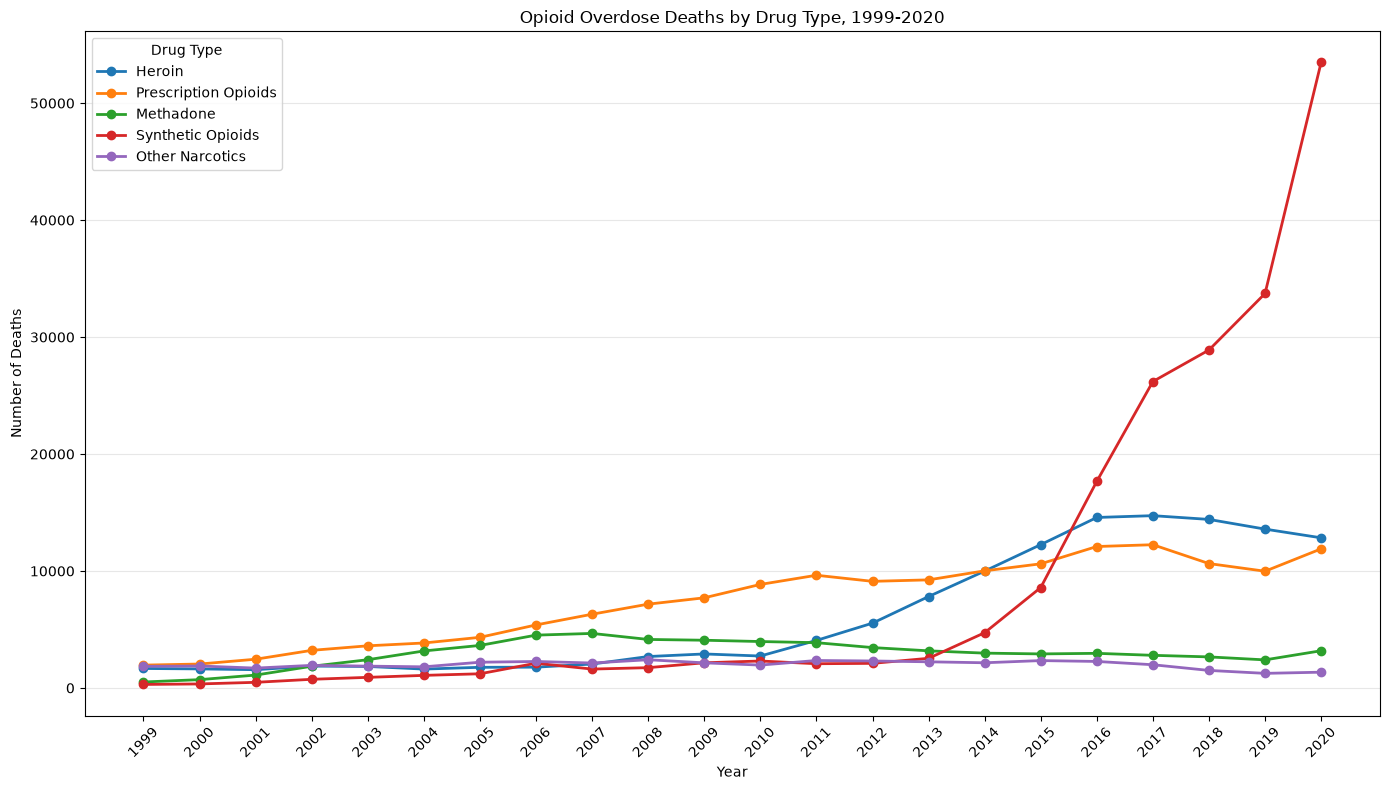

In [31]:
# Aggregate drug-specific deaths by year
drug_type_trend = (
    analysis_df.groupby("year", as_index=False)
    .agg(
        heroin_deaths=("heroin_deaths", "sum"),
        prescription_deaths=("prescription_deaths", "sum"),
        methadone_deaths=("methadone_deaths", "sum"),
        synthetic_deaths=("synthetic_deaths", "sum"),
        other_deaths=("other_deaths", "sum"),
    )
)

# Rename columns for cleaner chart labels
drug_labels = {
    "heroin_deaths": "Heroin",
    "prescription_deaths": "Prescription Opioids",
    "methadone_deaths": "Methadone",
    "synthetic_deaths": "Synthetic Opioids",
    "other_deaths": "Other Narcotics",
}

figures_dir = Path("../figures")
figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)

# Create multi-line time-series chart
plt.figure(figsize=(14, 8))

for column, label in drug_labels.items():
    plt.plot(
        drug_type_trend["year"],
        drug_type_trend[column],
        marker="o",
        linewidth=2,
        label=label,
    )

plt.title(
    "Opioid Overdose Deaths by Drug Type, 1999-2020"
)
plt.xlabel("Year")
plt.ylabel("Number of Deaths")

plt.xticks(
    drug_type_trend["year"],
    rotation=45,
)

plt.legend(
    title="Drug Type"
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_dir / "opioid_deaths_by_drug_type.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 5.2 Age-Based Analysis

In [22]:
# Create an age-by-year summary
age_year_trend = (
    age_analysis_df .groupby(["age", "year"], as_index=False)
    .agg(
        deaths=("deaths", "sum"),
        population=("population", "sum"),
    )
)

# Calculate opioid death rate per 100,000 population
age_year_trend["opioid_death_rate"] = (
    age_year_trend["deaths"]
    / age_year_trend["population"]
    * 100_000
)

# Preview the results
age_year_trend.head()

,age,year,deaths,population,opioid_death_rate
0,15.00,"2,020.00",22.00,"599,914.00",3.67
1,16.00,"2,020.00",29.00,"575,511.00",5.04
2,17.00,"2,004.00",10.00,"343,407.00",2.91
3,17.00,"2,006.00",20.00,"600,227.00",3.33
4,17.00,"2,009.00",11.00,"377,477.00",2.91


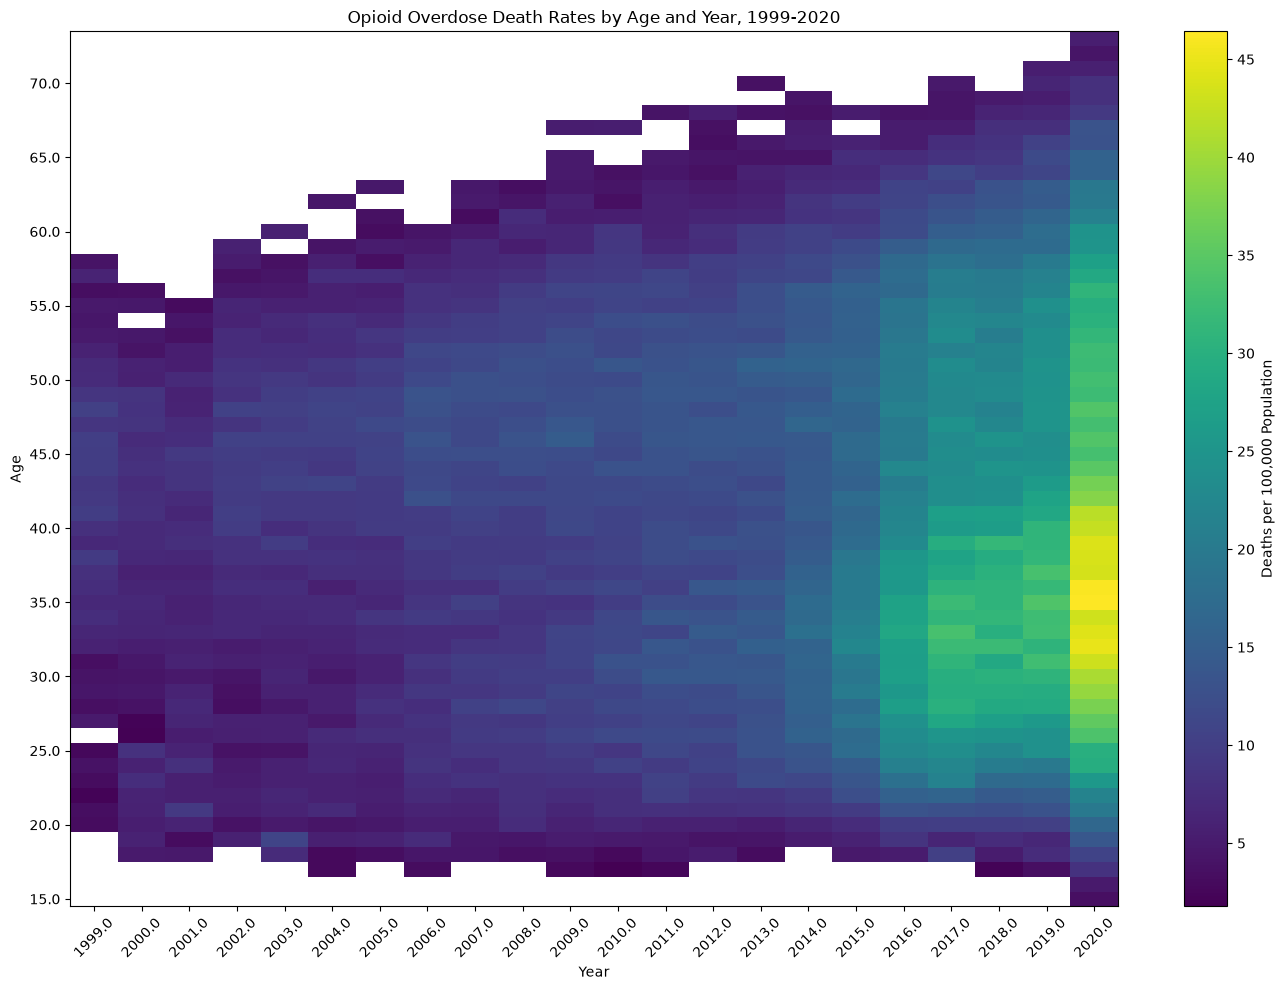

In [24]:
# Reshape the data for the heatmap
age_heatmap = age_year_trend.pivot(
    index="age",
    columns="year",
    values="opioid_death_rate",
)

# Create the heatmap
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(14, 10))

plt.imshow(
    age_heatmap,
    aspect="auto",
    origin="lower",
)

plt.colorbar(
    label="Deaths per 100,000 Population"
)

plt.title(
    "Opioid Overdose Death Rates by Age and Year, 1999-2020"
)
plt.xlabel("Year")
plt.ylabel("Age")

plt.xticks(
    ticks=range(len(age_heatmap.columns)),
    labels=age_heatmap.columns,
    rotation=45,
)

age_positions = range(
    0,
    len(age_heatmap.index),
    5,
)

plt.yticks(
    ticks=age_positions,
    labels=age_heatmap.index[::5],
)

plt.tight_layout()

plt.savefig(
    figures_dir / "opioid_death_rates_age_year_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 5.3 Sex-Based Analysis

In [25]:
# Aggregate deaths and population by sex and year
sex_year_trend = (
    sex_analysis_df.groupby(
        ["sex", "year"],
        as_index=False,
    )
    .agg(
        deaths=("deaths", "sum"),
        population=("population", "sum"),
    )
)

# Calculate opioid death rate per 100,000 population
sex_year_trend["opioid_death_rate"] = (
    sex_year_trend["deaths"]
    / sex_year_trend["population"]
    * 100_000
)

# Preview the results
sex_year_trend.head()

,sex,year,deaths,population,opioid_death_rate
0,Female,"1,999.00","1,179.00","142,237,347.00",0.83
1,Female,"2,000.00","1,383.00","143,368,343.00",0.96
2,Female,"2,001.00","1,704.00","145,077,463.00",1.17
3,Female,"2,002.00","2,451.00","146,394,634.00",1.67
4,Female,"2,003.00","2,858.00","147,679,036.00",1.94


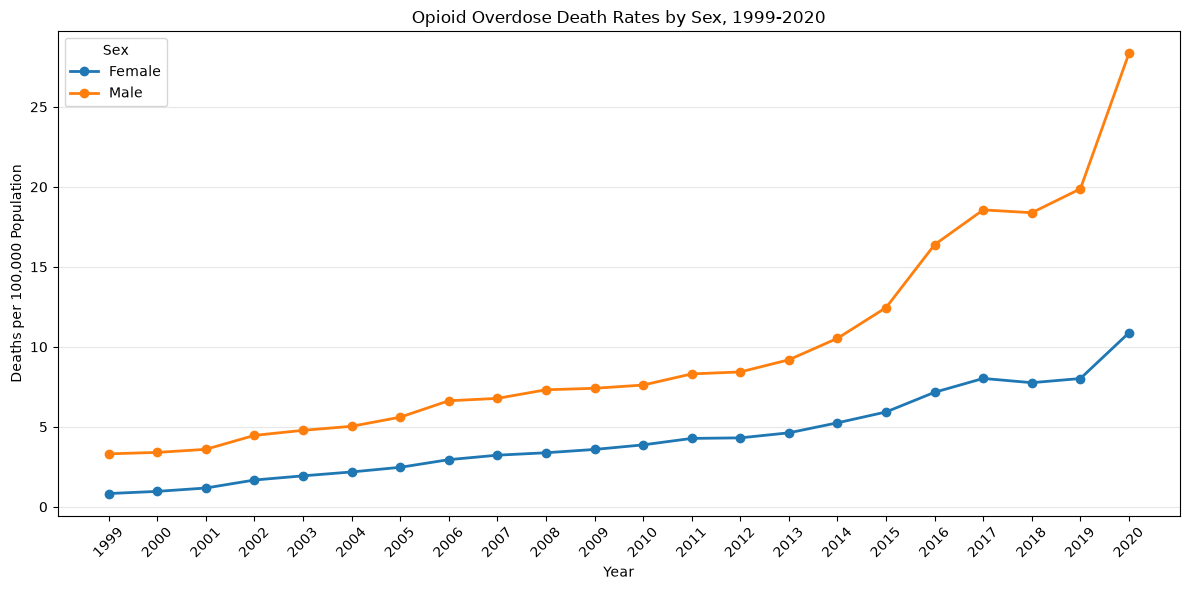

In [27]:
# Create a two-line time-series chart by sex
figures_dir = Path("../figures")
figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)

plt.figure(figsize=(12, 6))

for sex in sex_year_trend["sex"].unique():
    sex_data = sex_year_trend[
        sex_year_trend["sex"] == sex
    ]

    plt.plot(
        sex_data["year"],
        sex_data["opioid_death_rate"],
        marker="o",
        linewidth=2,
        label=sex,
    )

plt.title("Opioid Overdose Death Rates by Sex, 1999-2020")
plt.xlabel("Year")
plt.ylabel("Deaths per 100,000 Population")

plt.xticks(
    sex_year_trend["year"].unique(),
    rotation=45,
)

plt.legend(title="Sex")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_dir / "opioid_death_rates_by_sex.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### 5.4 Race/Ethnicity-Based Analysis

In [28]:
# Aggregate deaths and population by race/ethnicity and year
race_year_trend = (
    race_analysis_df.groupby(
        ["race", "year"],
        as_index=False,
    )
    .agg(
        deaths=("deaths", "sum"),
        population=("population", "sum"),
    )
)

# Calculate opioid death rate per 100,000 population
race_year_trend["opioid_death_rate"] = (
    race_year_trend["deaths"]
    / race_year_trend["population"]
    * 100_000
)

# Preview the results
race_year_trend.head()

,race,year,deaths,population,opioid_death_rate
0,American Indian or Alaska Native,"1,999.00",25.00,"2,832,784.00",0.88
1,American Indian or Alaska Native,"2,000.00",26.00,"2,984,150.00",0.87
2,American Indian or Alaska Native,"2,001.00",11.00,"3,097,333.00",0.36
3,American Indian or Alaska Native,"2,002.00",43.00,"3,202,471.00",1.34
4,American Indian or Alaska Native,"2,003.00",67.00,"3,312,011.00",2.02


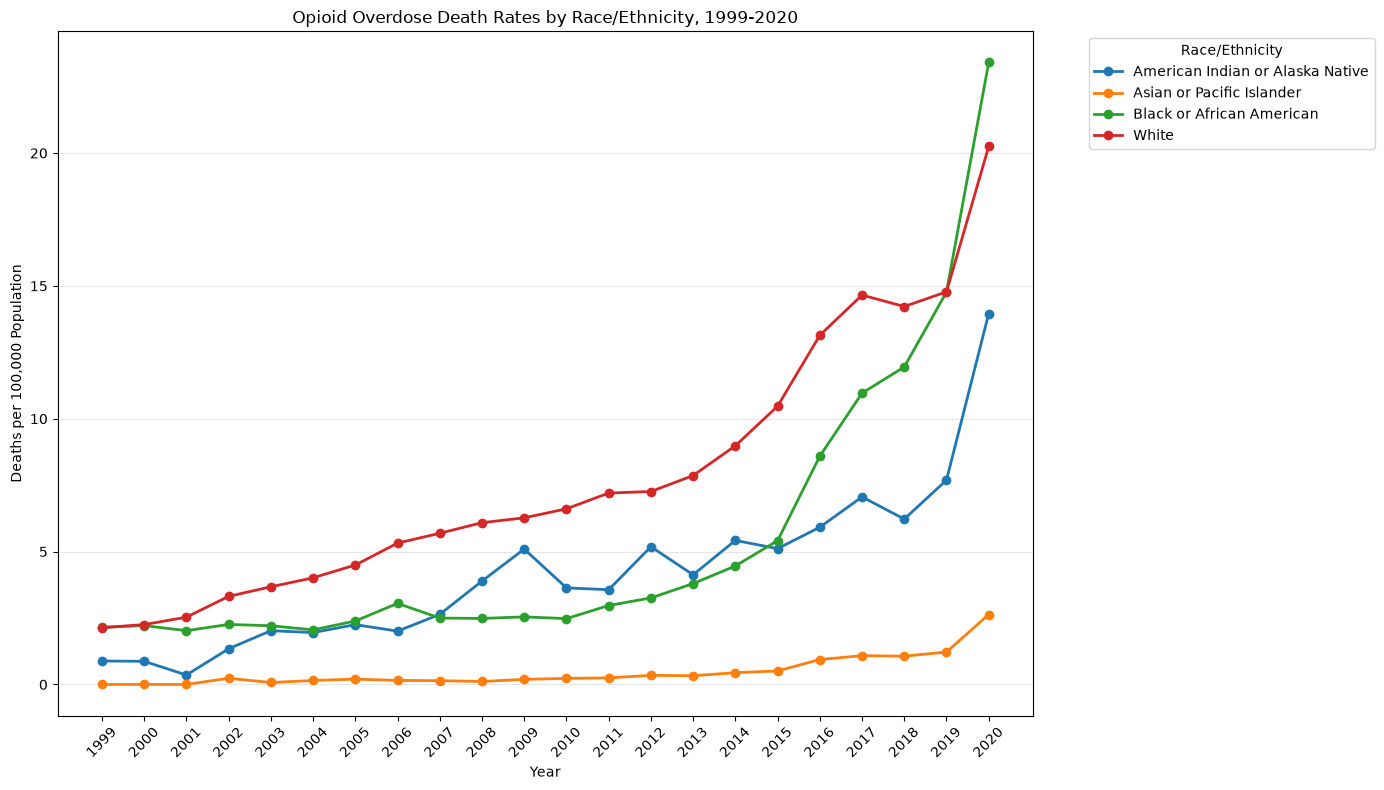

In [29]:
# Create a multi-line time-series chart by race/ethnicity
figures_dir = Path("../figures")
figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)

plt.figure(figsize=(14, 8))

for race in race_year_trend["race"].unique():
    race_data = race_year_trend[
        race_year_trend["race"] == race
    ]

    plt.plot(
        race_data["year"],
        race_data["opioid_death_rate"],
        marker="o",
        linewidth=2,
        label=race,
    )

plt.title(
    "Opioid Overdose Death Rates by Race/Ethnicity, 1999-2020"
)
plt.xlabel("Year")
plt.ylabel("Deaths per 100,000 Population")

plt.xticks(
    race_year_trend["year"].unique(),
    rotation=45,
)

plt.legend(
    title="Race/Ethnicity",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_dir / "opioid_death_rates_by_race_ethnicity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
